c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


📍 Thư mục đang chạy ô code: d:\YELLOWTAXI-NYC2021\Data\src\ML
📂 Đường dẫn chốt cuối cùng: D:/YELLOWTAXI-NYC2021/Data/processed/KPI_requirements/kpi_daily_2021.csv
✅ Thành công! Đã nạp xong 365 dòng dữ liệu vào biến 'df'.
📊 Tổng số ngày dữ liệu: 365
   - Train: 351 ngày (Kết thúc: 2021-12-17)
   - Test:  14 ngày (Bắt đầu: 2021-12-18)


20:26:41 - cmdstanpy - INFO - Chain [1] start processing


🚀 Đang huấn luyện mô hình Prophet (Chế độ thích ứng biến động)...


20:26:42 - cmdstanpy - INFO - Chain [1] done processing



🔍 KẾT QUẢ ĐÁNH GIÁ (TRÊN TẬP TEST 14 NGÀY)
MAE  (Sai số tuyệt đối): 19,745 chuyến/ngày
MAPE (Sai số phần trăm): 33.00%
⚠️ Đánh giá: Cần cải thiện tham số (<30%)

🔮 Đang dự báo cho 14 ngày tiếp theo (Chưa có dữ liệu)...

--- DỰ BÁO NHU CẦU 5 NGÀY TỚI ---
          ds          yhat    yhat_lower    yhat_upper
0 2022-01-01  30712.842657  24433.276629  37194.818020
1 2022-01-02  53914.670330  47388.232106  60027.157799
2 2022-01-03  63096.949445  56640.949971  69618.291288
3 2022-01-04  70022.391235  63112.689840  76423.176107
4 2022-01-05  73389.408706  66921.231120  80222.667197

✅ Đã lưu biểu đồ đánh giá tại folder figures


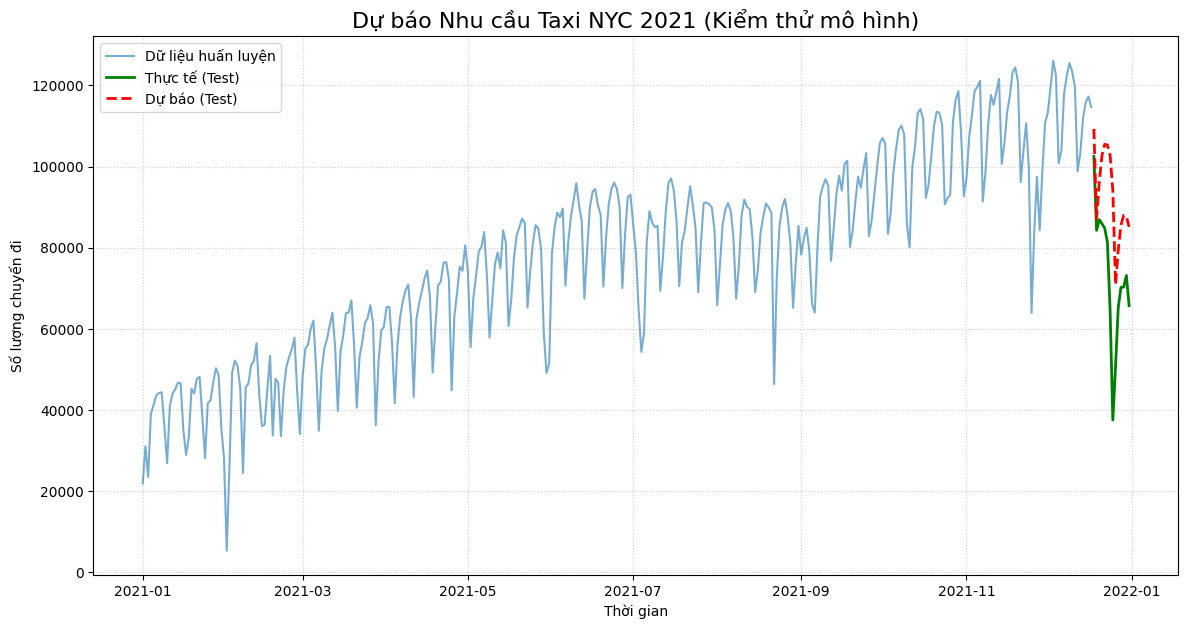

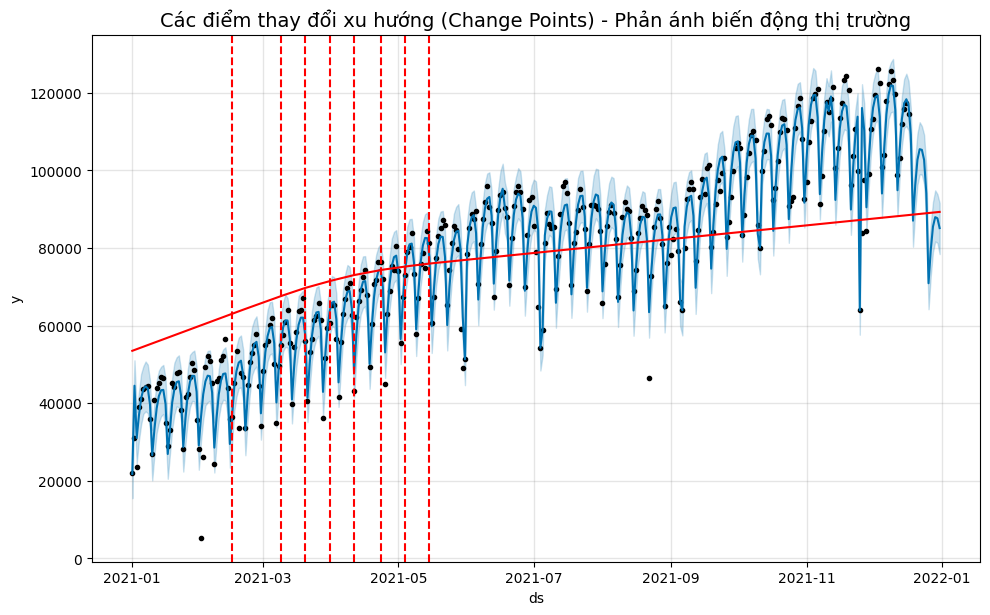

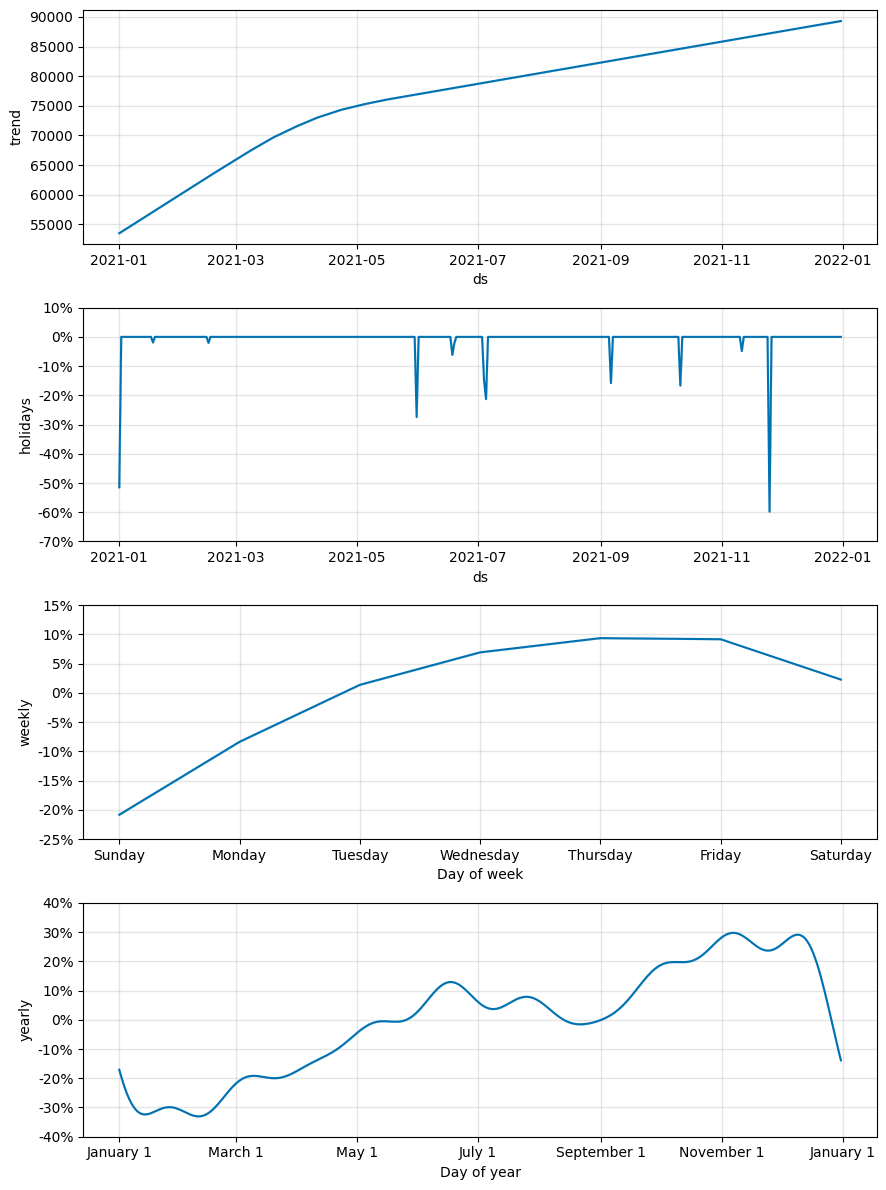


🎉 HOÀN TẤT! Hãy kiểm tra các biểu đồ để đưa vào báo cáo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import os

CURRENT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
print(f"📍 Thư mục đang chạy ô code: {CURRENT_DIR}")

# 2. Định vị đường dẫn tương đối an toàn (Fallback đa tầng, không dùng vòng lặp while)
# Cách 1: Thử đi lùi 2 tầng từ thư mục hiện tại (Dành cho src/source_figures/ hoặc src/ML/)
PATH_ATTEMPT_1 = os.path.abspath(os.path.join(CURRENT_DIR, "..", "..", "Data", "processed", "KPI_requirements", "kpi_daily_2021.csv"))

# Cách 2: Thử tìm trực tiếp từ thư mục hiện hành (Dành cho trường hợp chạy ngay tại gốc dự án)
PATH_ATTEMPT_2 = os.path.abspath(os.path.join(CURRENT_DIR, "Data", "processed", "KPI_requirements", "kpi_daily_2021.csv"))

# 3. Lựa chọn đường dẫn chính xác dựa trên sự tồn tại thực tế của file
if os.path.exists(PATH_ATTEMPT_1):
    FULL_PATH = PATH_ATTEMPT_1
elif os.path.exists(PATH_ATTEMPT_2):
    FULL_PATH = PATH_ATTEMPT_2
else:
    # Nếu cả 2 cách tìm tự động đều không thấy, ta ép cứng về ổ D của bạn cho chắc ăn
    FULL_PATH = "D:/YELLOWTAXI-NYC2021/Data/processed/KPI_requirements/kpi_daily_2021.csv"

print(f"📂 Đường dẫn chốt cuối cùng: {FULL_PATH}")

# 4. Kiểm tra sự tồn tại và đọc dữ liệu
if not os.path.exists(FULL_PATH):
    print("❌ LỖI: Bản kiểm tra cứng vẫn không tìm thấy file. Bạn hãy check lại tên file kpi_daily_2021.csv nhé!")
else:
    try:
        df = pd.read_csv(FULL_PATH)
        print(f"✅ Thành công! Đã nạp xong {len(df):,} dòng dữ liệu vào biến 'df'.")
    except Exception as e:
        print(f"❌ Lỗi khi nạp dữ liệu: {e}")

# =========================================================
# 2. TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)
# =========================================================
df_model = df[['pickup_date', 'trips']].rename(columns={'pickup_date': 'ds', 'trips': 'y'})
df_model['ds'] = pd.to_datetime(df_model['ds'])
df_model = df_model.sort_values('ds').reset_index(drop=True)

# Chia tập Train (Học) và Test (Kiểm tra)
TEST_DAYS = 14
train = df_model.iloc[:-TEST_DAYS]
test = df_model.iloc[-TEST_DAYS:]
print(f"📊 Tổng số ngày dữ liệu: {len(df_model)}")
print(f"   - Train: {len(train)} ngày (Kết thúc: {train['ds'].max().date()})")
print(f"   - Test:  {len(test)} ngày (Bắt đầu: {test['ds'].min().date()})")

# =========================================================
# 3. HUẤN LUYỆN MÔ HÌNH (CẤU HÌNH CHO DATA COVID/PHỤC HỒI)
# =========================================================
# Tinh chỉnh tham số quan trọng cho năm 2021 (Năm phục hồi sau đại dịch):
# 1. seasonality_mode='multiplicative': Vì biên độ dao động (cuối tuần vs ngày thường) 
#    tăng lên khi tổng lượng khách hồi phục.
# 2. changepoint_prior_scale=0.15 (Mặc định 0.05): Tăng độ linh hoạt để mô hình 
#    bắt kịp các đợt mở cửa/phong tỏa hoặc sự kiện lớn thay đổi xu hướng.

model = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=True, 
    daily_seasonality=False,
    seasonality_mode='multiplicative', 
    changepoint_prior_scale=0.15  # <--- QUAN TRỌNG: Tăng độ nhạy với thay đổi xu hướng
)

model.add_country_holidays(country_name='US')

print("🚀 Đang huấn luyện mô hình Prophet (Chế độ thích ứng biến động)...")
model.fit(train)

# =========================================================
# 4. ĐÁNH GIÁ MÔ HÌNH (EVALUATION)
# =========================================================
future_test = model.make_future_dataframe(periods=TEST_DAYS)
forecast = model.predict(future_test)

# Lấy dữ liệu 14 ngày cuối để so sánh
forecast_test = forecast.iloc[-TEST_DAYS:]
y_true = test['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("\n" + "="*40)
print("🔍 KẾT QUẢ ĐÁNH GIÁ (TRÊN TẬP TEST 14 NGÀY)")
print("="*40)
print(f"MAE  (Sai số tuyệt đối): {mae:,.0f} chuyến/ngày")
print(f"MAPE (Sai số phần trăm): {mape*100:.2f}%")

if mape < 0.1:
    print("🌟 Đánh giá: Mô hình RẤT TỐT (<10%)")
elif mape < 0.2:
    print("✅ Đánh giá: Mô hình TỐT (<20%)")
else:
    print("⚠️ Đánh giá: Cần cải thiện tham số (<30%)")

# =========================================================
# 5. DỰ BÁO TƯƠNG LAI & XUẤT KẾT QUẢ
# =========================================================
print("\n🔮 Đang dự báo cho 14 ngày tiếp theo (Chưa có dữ liệu)...")
# Tạo khung thời gian cho 14 ngày SAU KHI hết dữ liệu trong file
last_date = df_model['ds'].max()
future_next = model.make_future_dataframe(periods=TEST_DAYS + 14) 
# Lọc lấy đúng phần tương lai mới
future_days_only = future_next[future_next['ds'] > last_date].copy()

forecast_new = model.predict(future_days_only)

print("\n--- DỰ BÁO NHU CẦU 5 NGÀY TỚI ---")
print(forecast_new[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(5))

# =========================================================
# 6. TRỰC QUAN HÓA CHUYÊN SÂU (VISUALIZATION)
# =========================================================
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- BIỂU ĐỒ 1: SO KHỚP THỰC TẾ VS DỰ BÁO ---
plt.figure(figsize=(14, 7))
plt.plot(train['ds'], train['y'], label='Dữ liệu huấn luyện', color='#1f77b4', alpha=0.6)
plt.plot(test['ds'], test['y'], label='Thực tế (Test)', color='green', linewidth=2)
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Dự báo (Test)', color='red', linestyle='--', linewidth=2)
plt.title('Dự báo Nhu cầu Taxi NYC 2021 (Kiểm thử mô hình)', fontsize=16)
plt.xlabel('Thời gian')
plt.ylabel('Số lượng chuyến đi')
plt.legend()    
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(os.path.join(FIGURES_DIR, 'forecast_evaluation.png'), dpi=150)
print(f"\n✅ Đã lưu biểu đồ đánh giá tại folder {FIGURES_DIR}")
plt.show()

# --- BIỂU ĐỒ 2: PHÂN TÍCH ĐIỂM GÃY XU HƯỚNG (CHANGE POINTS) ---
# Biểu đồ này cực kỳ quan trọng để giải thích yếu tố COVID
fig_cp = model.plot(forecast)
a = add_changepoints_to_plot(fig_cp.gca(), model, forecast)
plt.title('Các điểm thay đổi xu hướng (Change Points) - Phản ánh biến động thị trường', fontsize=14)
plt.savefig(os.path.join(FIGURES_DIR, 'forecast_changepoints.png'), dpi=150)
plt.show()

# --- BIỂU ĐỒ 3: PHÂN RÃ CÁC THÀNH PHẦN ---
fig_comp = model.plot_components(forecast)
plt.savefig(os.path.join(FIGURES_DIR, 'forecast_components.png'), dpi=150)
plt.show()

print("\n🎉 HOÀN TẤT! Hãy kiểm tra các biểu đồ để đưa vào báo cáo.")